# 14_01 — Simulación y preprocesamiento · Escenario 4 (Algoritmo 4 del anexo)

Paso **1 de 3** del ciclo `Python → MATLAB → Python`:

| Paso | Archivo | Qué hace |
|---|---|---|
| 1 | **este notebook** | genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR y todos los artefactos |
| 2 | `psbp_fd_iteracion.m` | muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento |
| 3 | `14_03_convergencia` / `14_04_evaluacion` | diagnóstico de cadenas y evaluación fuera de muestra |

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de
experimento. Todo lo demás se deriva de ellas.

## 1. Imports y rutas

In [2]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenario4, generar_escenario_4, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.utils.quadrature import pesos_trapezoidales
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento

In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario"
ESCENARIO_ID = 4      # Algoritmo k del anexo
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")

PROJECT_ROOT  : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_ID : escenario_4_r01
Escenario 4 · réplica 1 · seed base 41232


In [4]:
# Las cinco rutas del contrato. No existe un config_paths en Python: cada
# notebook lo arma aquí y config_paths.m replica las mismas del lado MATLAB.
PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for nombre, ruta in PATHS.items():
    ruta.mkdir(parents=True, exist_ok=True)
    print(f"  {nombre:12s} → {ruta}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_4_r01
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_4_r01
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_4_r01
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_4_r01
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_4_r01


## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador


In [5]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 75     # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 400    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau), Cuadro tab:ane_esquema. Con nombre para que
    quede legible en el JSON."""
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario4(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 200,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Dinámica: IDÉNTICA a la del Algoritmo 1 (Cuadro tab:ane_alg4)
    gamma     = 0.30,
    hs_norm   = 0.70,   # ← 0.70 por decisión; el default del código es 0.50
    sigma_eps = 1.0,
    ell       = 0.2,
    # Ley de la innovación: lo ÚNICO que distingue a este escenario
    familia       = "st",
    delta_skew    = 0.85,
    forma_skew_fn = None,   # None ⇒ asimetría constante sobre el dominio
    nu            = 5.0,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")

  L                       : 75
  T                       : 400
  burn_in                 : 200
  sigma_obs               : 0.25
  R                       : 1
  seed                    : 41232
  media_fn                : media_senoidal
  jitter                  : 1e-10
  gamma                   : 0.3
  hs_norm                 : 0.7
  sigma_eps               : 1.0
  ell                     : 0.2
  familia                 : st
  delta_skew              : 0.85
  forma_skew_fn           : None
  nu                      : 5.0
  escala_contaminacion    : 0.2


### 2.2 Generación

In [6]:
salida = generar_escenario_4(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw   = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true  = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla  = salida.grilla
T, G    = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:36s} = {v}")

Observadas (400, 75) · verdaderas (400, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2505   (nominal 0.25)

Control de calidad del generador:
  n_replicas                           = 1
  n_curvas                             = 400
  n_puntos_grilla                      = 75
  todo_finito                          = True
  media_empirica_global                = 0.09639938558953823
  media_ee_montecarlo                  = nan
  var_puntual_media                    = 1.5101292340883972
  var_puntual_min                      = 1.0277786730042886
  var_puntual_max                      = 1.7752387398729215
  acf1_media                           = 0.5404223308615015
  acf1_ee_montecarlo                   = nan
  razon_senal_ruido                    = 24.162067745414355
  familia                              = st
  delta_skew                           = 0.85
  nu                                   = 5.0
  k1_E_W_menos_media                   = 1.189416077435181
  k2_E_W_i

In [7]:
simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico":   salida.diagnostico,
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "escenario_id":  int(ESCENARIO_ID),
    "replica_id":    int(REPLICA_ID),
    "seed":          SEED,
    "T": int(T), "G": int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
    json.dump(simulation_config, f, indent=2, ensure_ascii=False)

# incluir_internos=True guarda `interno_operador`, `interno_delta_skew` y la
# covarianza teórica de la innovación. Ninguno entra en la estimación; sirven
# para documentar el generador y para rehacer el diagnóstico.
_npz = guardar_escenario(salida, str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}"),
                         incluir_curvas=True, incluir_internos=True)
print(f"[raw] simulation_config.json  ·  {_npz}")

[raw] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_4_r01\escenario_4.npz


#### Lectura del control de calidad




In [8]:
_d = salida.diagnostico

# ── ESTRUCTURALES: si fallan, el generador no es el del anexo ────────────────
_estructurales = [
    ("trayectorias finitas",                 _d["todo_finito"],
     f"{_d['n_replicas']}×{_d['n_curvas']}×{_d['n_puntos_grilla']}"),
    ("estacionariedad garantizada",          _d["estacionariedad_garantizada"],
     f"radio espectral = {_d['radio_espectral_operador']:.4f}"),
    ("calibración de la norma HS",           _d["hs_norm_error_absoluto"] < 1e-8,
     f"objetivo {_d['hs_norm_objetivo']} · efectiva {_d['hs_norm_efectiva']:.6f}"),
    ("calibración de la escala de eps",      _d["var_innovacion_teorica_error_max"] < 1e-10,
     f"objetivo {_d['var_innovacion_objetivo']:.4f} · "
     f"empírica {_d['var_innovacion_empirica_media']:.4f}"),
]
for nombre, ok, detalle in _estructurales:
    print(f"  {'OK ' if ok else 'FALLA'}  {nombre:34s} {detalle}")

assert all(ok for _, ok, _ in _estructurales), \
    "El generador no cumple las condiciones estructurales del Algoritmo 4."

# ── INFORMATIVOS: con R = 1 son cifras ruidosas; se reportan, no se exigen ───
print("\nAsimetría y colas (informativo, R = 1):")
print(f"  delta_skew (parámetro)          : {_d['delta_skew']:.3f}   "
      f"familia {_d['familia']} · nu {_d['nu']:.1f}")
print(f"  asimetría de la INNOVACIÓN      : {_d['asimetria_innovacion_empirica']:+.4f}")
print(f"  curtosis  de la INNOVACIÓN      : {_d['curtosis_innovacion_empirica']:.4f}"
      f"   (gaussiana = 3)")
print(f"  asimetría de las CURVAS         : {_d['asimetria_curvas_media']:+.4f}")
print(f"  curtosis  de las CURVAS         : {_d['curtosis_curvas_media']:.4f}")
print(f"  razón curva/innovación          : {_d['razon_asimetria_curva_innovacion']:.4f}"
      f"   ← cuánta asimetría sobrevive a la agregación")
print(f"  exceso de correlación a larga distancia: "
      f"{_d['correlacion_larga_distancia_extra']:.4f}")

if abs(_d["asimetria_curvas_media"]) < 0.2:
    print("\n[AVISO] La asimetría de la curva es pequeña: el escenario "
          "difícilmente separará\n  métodos gaussianos de no gaussianos. "
          "Revisar delta_skew, hs_norm o ell antes de\n  gastar el MCMC.")
else:
    print(f"\n  La curva conserva asimetría apreciable: el escenario tiene "
          f"contenido para 14_04 §9.")

  OK   trayectorias finitas               1×400×75
  OK   estacionariedad garantizada        radio espectral = 0.6215
  OK   calibración de la norma HS         objetivo 0.7 · efectiva 0.700000
  OK   calibración de la escala de eps    objetivo 1.0000 · empírica 1.0280

Asimetría y colas (informativo, R = 1):
  delta_skew (parámetro)          : 0.850   familia st · nu 5.0
  asimetría de la INNOVACIÓN      : +1.7256
  curtosis  de la INNOVACIÓN      : 15.8761   (gaussiana = 3)
  asimetría de las CURVAS         : +0.5724
  curtosis  de las CURVAS         : 3.7302
  razón curva/innovación          : 0.3317   ← cuánta asimetría sobrevive a la agregación
  exceso de correlación a larga distancia: 0.5448

  La curva conserva asimetría apreciable: el escenario tiene contenido para 14_04 §9.


### 2.3 Visualización de los datos

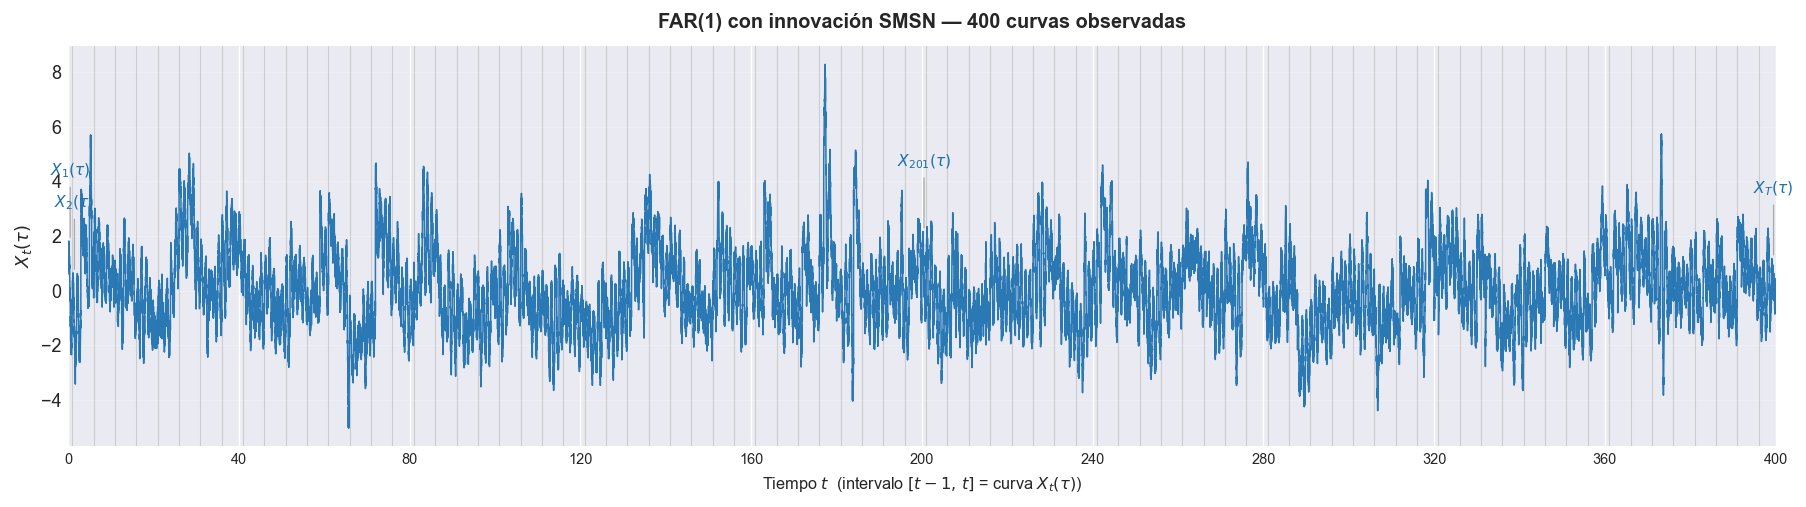

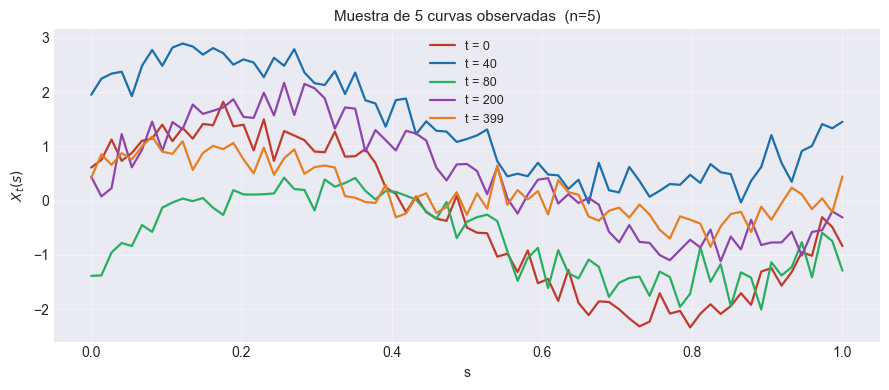

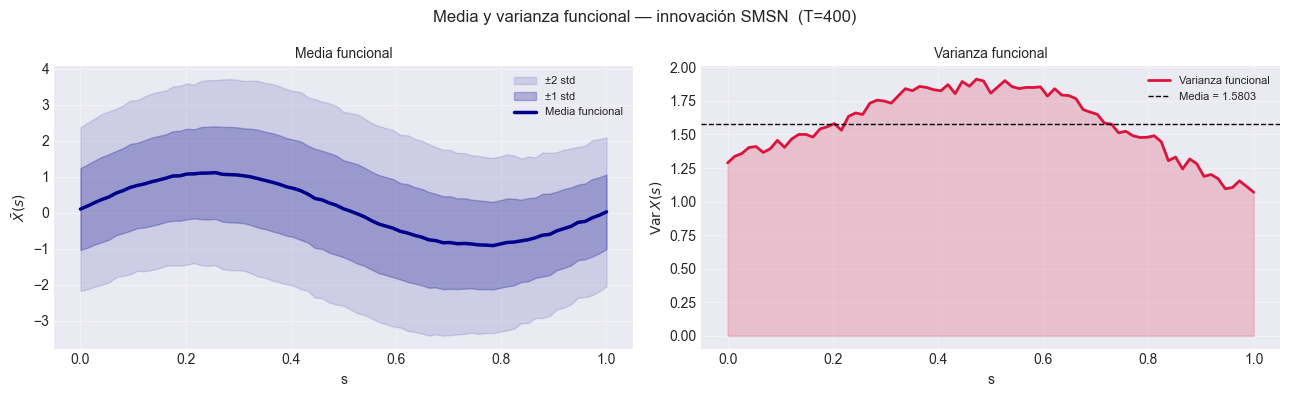

In [9]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) con innovación SMSN — {T} curvas observadas",
    save_path=str(PATHS["out_report"] / "01_fts_empirica_raw.png"))
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas",
    save_path=str(PATHS["out_report"] / "02_muestra_empirica_raw.png"))
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — innovación SMSN",
    save_path=str(PATHS["out_report"] / "03_media_varianza_raw.png"))
plt.show()

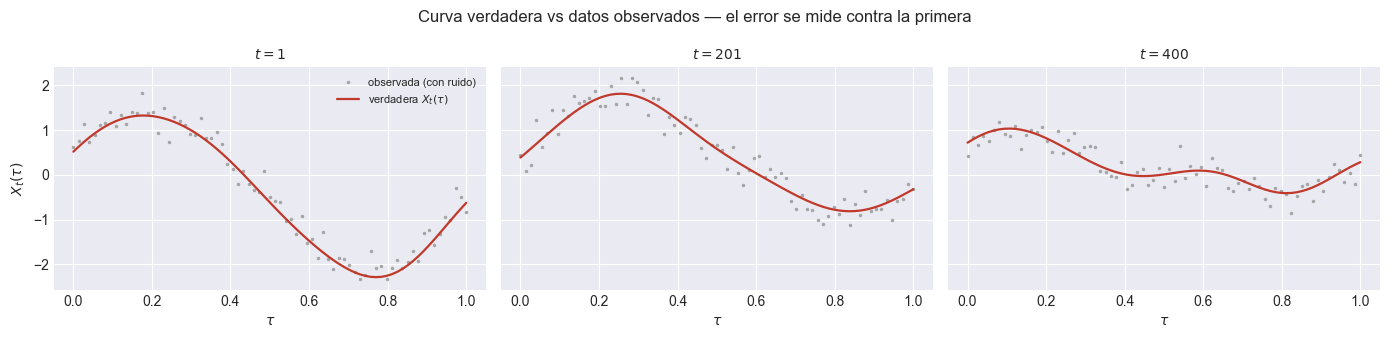

In [10]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10)
    ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "04_curva_vs_datos.png", dpi=150, bbox_inches="tight")
plt.show()

#### El rasgo del escenario: la asimetría

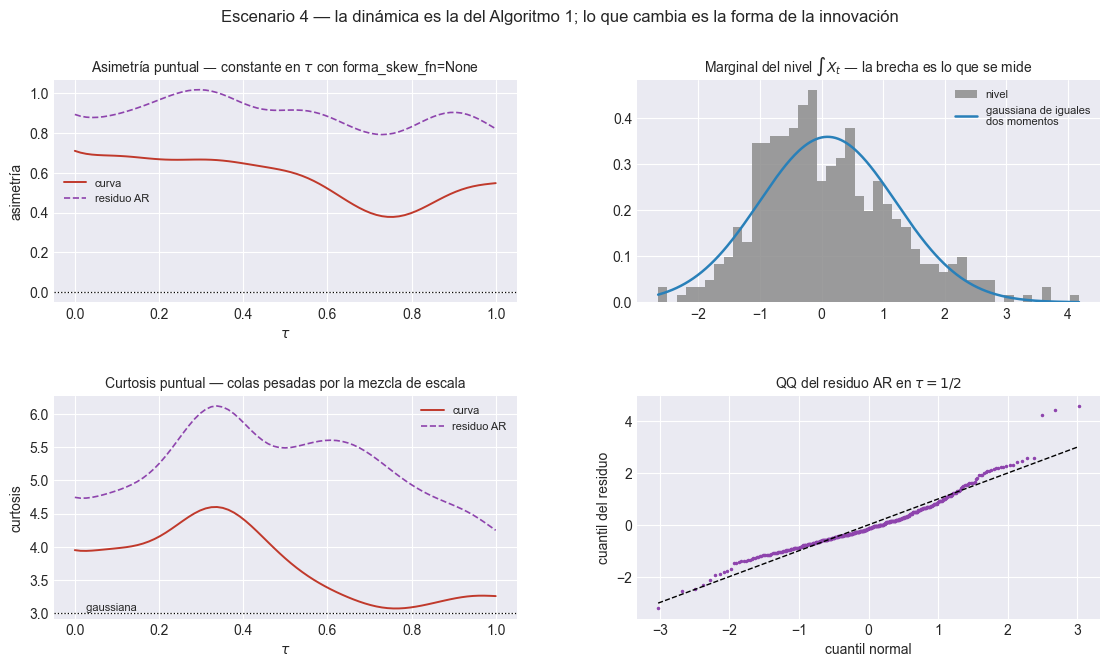

asimetría media de la curva   : +0.5724   (dispersión en tau 0.1066)
asimetría media del residuo AR: +0.9014   (diagnóstico del generador: +1.7256)
curtosis media del residuo AR : 5.2481
asimetría del nivel           : +0.5900

  El residuo AR reconstruido reproduce la asimetría de la innovación.


In [11]:
w_quad  = pesos_trapezoidales(grilla)
Psi_op  = salida.internos["operador"]        # (G, G) el operador AR discretizado
mu_true = salida.media                       # (G,)

def _asim_curt(Z, eje=0):
    """Asimetría y curtosis (no exceso), estandarizadas."""
    Zc = Z - Z.mean(axis=eje, keepdims=True)
    m2 = np.mean(Zc ** 2, axis=eje)
    sd = np.sqrt(np.where(m2 > 0, m2, np.nan))
    return (np.mean(Zc ** 3, axis=eje) / sd ** 3,
            np.mean(Zc ** 4, axis=eje) / sd ** 4)

# Residuo AR: reconstruye la innovación desde las curvas VERDADERAS.
# El operador actúa sobre la curva centrada, tal como en el generador.
Y_estado = X_true - mu_true[None, :]                     # (T, G)
RESIDUO  = Y_estado[1:] - Y_estado[:-1] @ Psi_op.T       # (T-1, G)

asim_tau,  curt_tau  = _asim_curt(X_true)                # por punto del dominio
asim_res,  curt_res  = _asim_curt(RESIDUO)
nivel = (X_true * w_quad).sum(axis=1)                    # <X_t, 1>

fig = plt.figure(figsize=(13.5, 7.0))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.26)

# (a) asimetría y curtosis puntuales a lo largo del dominio
ax = fig.add_subplot(gs[0, 0])
ax.plot(grilla, asim_tau, color="#c0392b", lw=1.4, label="curva")
ax.plot(grilla, asim_res, color="#8e44ad", lw=1.2, ls="--", label="residuo AR")
ax.axhline(0.0, color="k", lw=0.9, ls=":")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("asimetría")
ax.legend(fontsize=8)
ax.set_title("Asimetría puntual — constante en $\\tau$ con forma_skew_fn=None",
             fontsize=10)

# (b) marginal del nivel contra la gaussiana de iguales dos momentos
ax = fig.add_subplot(gs[0, 1])
ax.hist(nivel, bins=45, density=True, color="0.55", alpha=0.85, label="nivel")
_x = np.linspace(nivel.min(), nivel.max(), 300)
_g = np.exp(-0.5 * ((_x - nivel.mean()) / nivel.std()) ** 2) / (
    nivel.std() * np.sqrt(2 * np.pi))
ax.plot(_x, _g, color="#2980b9", lw=1.8, label="gaussiana de iguales\ndos momentos")
ax.legend(fontsize=8)
ax.set_title("Marginal del nivel $\\int X_t$ — la brecha es lo que se mide",
             fontsize=10)

# (c) curtosis puntual
ax = fig.add_subplot(gs[1, 0])
ax.plot(grilla, curt_tau, color="#c0392b", lw=1.4, label="curva")
ax.plot(grilla, curt_res, color="#8e44ad", lw=1.2, ls="--", label="residuo AR")
ax.axhline(3.0, color="k", lw=0.9, ls=":")
ax.text(0.02, 3.0, " gaussiana", fontsize=8, va="bottom")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("curtosis")
ax.legend(fontsize=8)
ax.set_title("Curtosis puntual — colas pesadas por la mezcla de escala",
             fontsize=10)

# (d) QQ del residuo AR contra la normal
ax = fig.add_subplot(gs[1, 1])
_r = np.sort((RESIDUO[:, G // 2] - RESIDUO[:, G // 2].mean())
             / RESIDUO[:, G // 2].std())
from scipy.stats import norm as _norm
_q = _norm.ppf((np.arange(1, _r.size + 1) - 0.5) / _r.size)
ax.plot(_q, _r, ".", ms=3, color="#8e44ad")
ax.plot([_q.min(), _q.max()], [_q.min(), _q.max()], "k--", lw=1)
ax.set_xlabel("cuantil normal"); ax.set_ylabel("cuantil del residuo")
ax.set_title(r"QQ del residuo AR en $\tau=1/2$", fontsize=10)

fig.suptitle("Escenario 4 — la dinámica es la del Algoritmo 1; lo que cambia es "
             "la forma de la innovación", fontsize=12)
fig.savefig(PATHS["out_report"] / "10_asimetria.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"asimetría media de la curva   : {np.nanmean(asim_tau):+.4f}   "
      f"(dispersión en tau {np.nanstd(asim_tau):.4f})")
print(f"asimetría media del residuo AR: {np.nanmean(asim_res):+.4f}   "
      f"(diagnóstico del generador: "
      f"{salida.diagnostico['asimetria_innovacion_empirica']:+.4f})")
print(f"curtosis media del residuo AR : {np.nanmean(curt_res):.4f}")
print(f"asimetría del nivel           : {float(_asim_curt(nivel[:, None])[0][0]):+.4f}")

# Verificación: el residuo reconstruido debe reproducir la asimetría que el
# generador declara para la innovación. No es exacto —son muestras distintas y
# el residuo hereda la incertidumbre de una sola trayectoria— pero el signo y
# el orden de magnitud deben coincidir.
_a_gen = salida.diagnostico["asimetria_innovacion_empirica"]
_a_res = float(np.nanmean(asim_res))
assert np.sign(_a_res) == np.sign(_a_gen) and abs(_a_res - _a_gen) < 0.5 * abs(_a_gen) + 0.3, (
    f"El residuo AR reconstruido tiene asimetría {_a_res:+.4f} y el generador "
    f"declara {_a_gen:+.4f}: revisar el centrado o el operador.")
print("\n  El residuo AR reconstruido reproduce la asimetría de la innovación.")

#### Persistencia de los momentos de la curva

Se guarda como CSV —y no sólo dentro del `.npz`— por la misma razón que la
corrida 13 guarda el régimen: es el insumo de la sección propia de `14_04` y
conviene que sea legible y versionable sin abrir un binario.

**Diferencia con las corridas 12 y 13**: esto **no** es un estado latente por
el que se pueda estratificar. Es una propiedad constante del proceso, no una
variable que cambie de origen a origen. Por eso `eval_config.json` declara
`estratificacion: null` con su motivo, y `14_04` omite la sección de
calibración condicional en lugar de fabricar estratos artificiales.

In [12]:
momentos_df = pd.DataFrame({
    "tau":                grilla,
    "asimetria_curva":    asim_tau,
    "curtosis_curva":     curt_tau,
    "asimetria_residuo":  np.concatenate([asim_res]),
    "curtosis_residuo":   np.concatenate([curt_res]),
    "var_curva":          X_true.var(axis=0),
})
momentos_df.to_csv(PATHS["out_report"] / "10_momentos_curva.csv", index=False)
print(f"[out_report] 10_momentos_curva.csv  {momentos_df.shape}")

# Serie del nivel y del residuo, por si 14_04 necesita el detalle por origen.
serie_df = pd.DataFrame({
    "t":               np.arange(1, T + 1),
    "nivel_curva":     nivel,
    "nivel_residuo":   np.concatenate([[np.nan], (RESIDUO * w_quad).sum(axis=1)]),
})
serie_df.to_csv(PATHS["out_report"] / "10_serie_residuo.csv", index=False)
print(f"[out_report] 10_serie_residuo.csv   {serie_df.shape}")
display(momentos_df.head())

[out_report] 10_momentos_curva.csv  (75, 6)
[out_report] 10_serie_residuo.csv   (400, 3)


,tau,asimetria_curva,curtosis_curva,asimetria_residuo,curtosis_residuo,var_curva
0,0.000000,0.709921,3.947358,0.892846,4.744432,1.256982
1,0.013514,0.700997,3.937127,0.884165,4.732320,1.265513
2,0.027027,0.695017,3.935853,0.879217,4.733513,1.275122
3,0.040541,0.691249,3.940092,0.877446,4.744348,1.285923
4,0.054054,0.689006,3.947208,0.878321,4.761784,1.298011


### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [13]:
_p = guardar_curvas(PATHS, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} → {ruta.name}")

[functional] curvas       → X_curves.npy
[functional] grilla       → domain_grid.npy
[functional] curvas_true  → X_curves_true.npy


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

A diferencia de la corrida 13, aquí no hay composición de estados que pueda
diferir entre bloques: el proceso es homogéneo en el tiempo. Cualquier
diferencia train/test es generalización, sin más.

In [14]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t en [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t en [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

# El proceso es homogéneo: la asimetría no debería cambiar entre bloques. Si lo
# hiciera de forma marcada, sería ruido de una sola trayectoria y no un rasgo.
_a_tr = float(np.nanmean(_asim_curt(X_true[idx_train])[0]))
_a_te = float(np.nanmean(_asim_curt(X_true[idx_test])[0]))
print(f"\nasimetría media de la curva  train={_a_tr:+.4f}  test={_a_te:+.4f}")
if abs(_a_te - _a_tr) > 0.4:
    print("[AVISO] La asimetría difiere entre bloques. Con R = 1 es ruido "
          "muestral esperable,\n  pero conviene tenerlo presente al leer 14_04 §9.")

entrenamiento : t en [1, 280]      → (280, 75)
prueba        : t en [281, 400]  → (120, 75)
proporción    : 70.0% / 30.0%

asimetría media de la curva  train=+0.6905  test=+0.1370
[AVISO] La asimetría difiere entre bloques. Con R = 1 es ruido muestral esperable,
  pero conviene tenerlo presente al leer 14_04 §9.


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,75.7362%,0.606099,1.587622,0.426485
1,3,2,80.8418%,0.536660,1.316055,0.346162
2,4,2,94.0197%,0.311215,0.568814,0.111121
3,5,2,95.4825%,0.272041,0.560076,0.086355
4,6,2,96.1750%,0.251264,0.337388,0.075253
5,7,2,96.3936%,0.244153,0.312862,0.073054
6,8,2,96.4996%,0.240528,0.302467,0.073040
7,9,2,96.6037%,0.236894,0.301410,0.073032
8,10,2,96.6700%,0.234568,0.300609,0.073826
9,11,2,96.7304%,0.232458,0.294351,0.074770



GCV mínimo → n_basis=8, order=4  (var retenida 96.5675%)


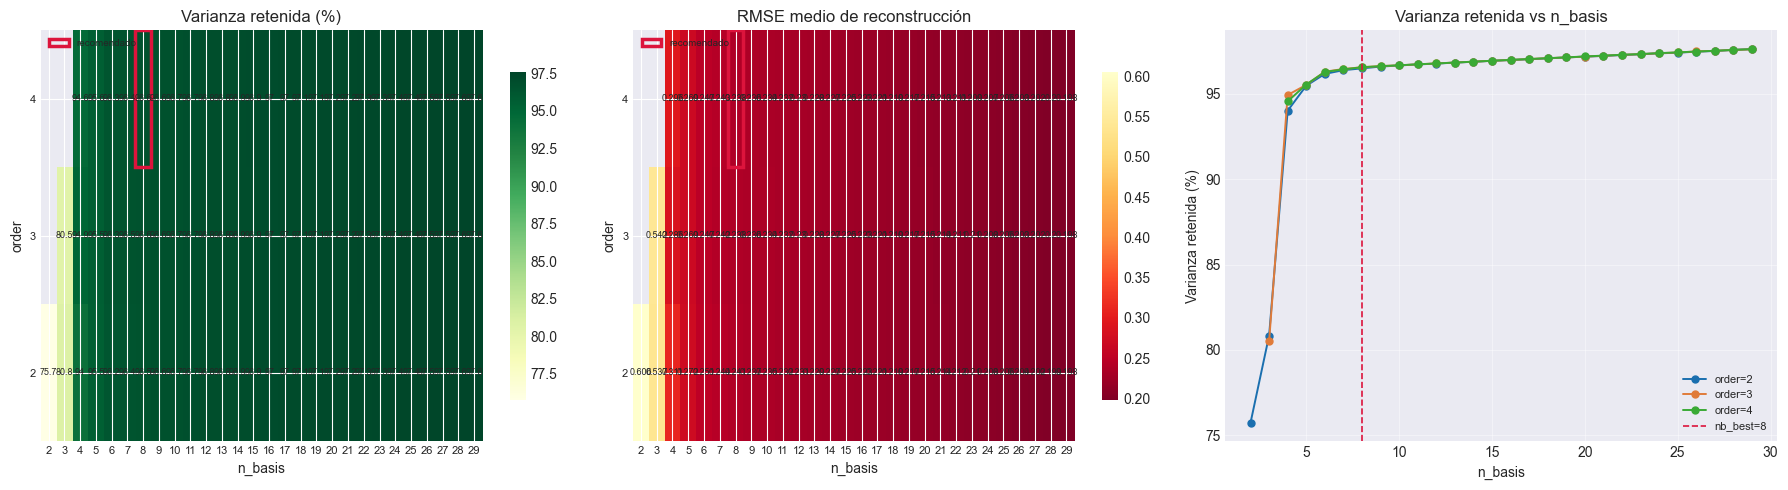

In [15]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best,
                     save_path=str(PATHS["out_report"] / "05_seleccion_basis.png"))
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=8, order=4
Sugerido GCV : n_basis=8, order=4   (coinciden)
THETA (400, 8)  (train=280, test=120)


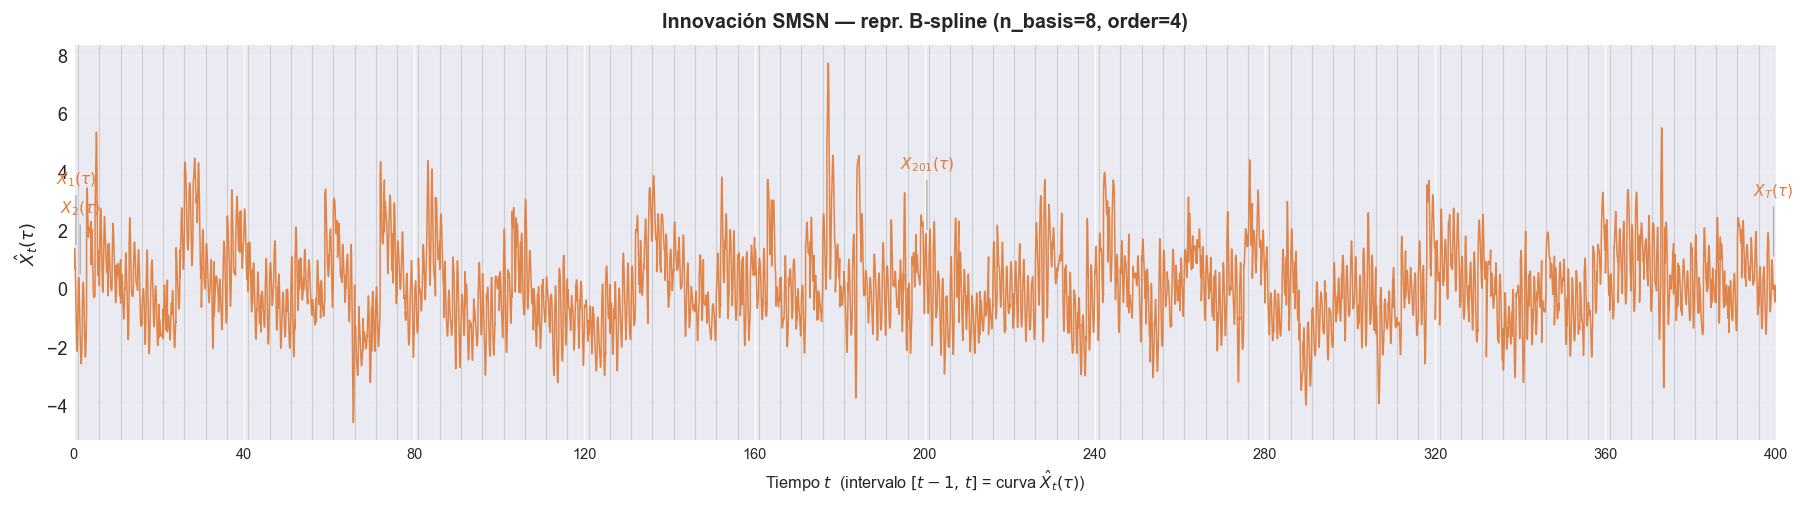

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [16]:
NB_ELEGIDO  = 8     # ← decisión del analista
ORD_ELEGIDO = 4

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"Innovación SMSN — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    save_path=str(PATHS["out_report"] / "06_fts_funcional_bspline.png"))
plt.show()

guardar_representacion(PATHS, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [17]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 8
  K                                  = 8
  n_ajuste                           = 280
  cond_W                             = 2.745e+01
  err_ortonormalidad_L2              = 2.887e-15
  err_ortonormalidad_gram            = 4.441e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.427e-16
  err_media_scores_rel               = 1.220e-15
  err_var_scores_vs_lambda           = 1.998e-15
  err_var_scores_vs_lambda_rel       = 5.480e-14
  err_correlacion_lag0               = 5.642e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio,asimetria_score,curtosis_score
0,1,1.3529e+00,83.5420%,83.5420%,+0.643,-0.740,3.382
1,2,1.5157e-01,9.3595%,92.9015%,+0.187,-0.613,4.655
2,3,7.1652e-02,4.4244%,97.3259%,+0.159,+0.101,3.505
3,4,2.7475e-02,1.6965%,99.0224%,+0.119,+0.085,3.708
4,5,9.9144e-03,0.6122%,99.6346%,+0.063,+0.174,4.147
5,6,3.9512e-03,0.2440%,99.8786%,-0.020,-0.237,3.706
6,7,1.0635e-03,0.0657%,99.9443%,-0.074,-0.217,3.274
7,8,9.0218e-04,0.0557%,100.0000%,-0.014,+0.039,3.071



K disponibles: 8   ·   sugerencia (var >= 95%): M = 3
componente con más asimetría: FPC 1 (asimetría -0.740, curtosis 3.382)
   ← es donde 14_04 §9 debería ver el fallo de una predictiva simétrica


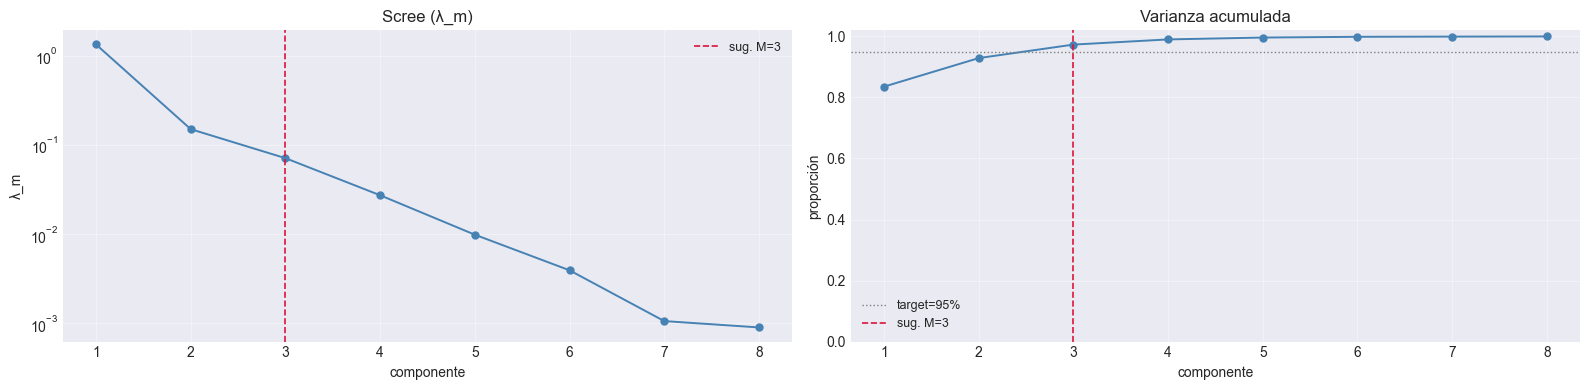

In [18]:
# Varianza ≠ dinámica. En este escenario se agrega una tercera columna propia:
# `asimetria_score`, la asimetría muestral del score en el bloque de
# entrenamiento. Dice QUÉ componente hereda la asimetría de la innovación, y
# por tanto en cuál debería verse el fallo de una predictiva simétrica en
# 14_04 §9. Con un choque asimétrico común a todo el dominio, la carga debería
# concentrarse en la componente que representa el nivel de la curva.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)
asim_score = _asim_curt(S_a)[0]
curt_score = _asim_curt(S_a)[1]

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum,
    "ar1_propio": ar1, "asimetria_score": asim_score, "curtosis_score": curt_score,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}", "var_acum": "{:.4%}",
     "ar1_propio": "{:+.3f}", "asimetria_score": "{:+.3f}",
     "curtosis_score": "{:.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1)
    .background_gradient(subset=["asimetria_score"], cmap="PuOr", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var >= {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
_k_asim = int(np.argmax(np.abs(asim_score)))
print(f"componente con más asimetría: FPC {_k_asim + 1} "
      f"(asimetría {asim_score[_k_asim]:+.3f}, curtosis {curt_score[_k_asim]:.3f})")
print("   ← es donde 14_04 §9 debería ver el fallo de una predictiva simétrica")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET,
                save_path=str(PATHS["out_report"] / "07_fpca_scree.png"))
plt.show()

### 3.4 `[CONFIG]` Componentes FPCA retenidas

In [19]:
M_FPCA = 3   # ← INVARIANTE del estudio: igual que las corridas 11 y 12, para
             #   que M no sea un segundo factor en la comparación entre
             #   escenarios. La comparación 11 vs 14 exige que coincida.

assert 1 <= M_FPCA <= fpca.evals.size, f"M_FPCA fuera de [1, {fpca.evals.size}]."
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (aprox 0)")
print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
print(f"[test]  var xi / lambda = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

_asim_ret = np.abs(asim_score[:M_fpca]).max()
print(f"\nasimetría máxima entre las {M_fpca} componentes retenidas: "
      f"{_asim_ret:.3f}")
if _asim_ret < 0.2:
    print("[AVISO] Ninguna componente retenida hereda asimetría apreciable: "
          "14_04 §9 no\n  tendrá contenido. Con la asimetría de curva de §2.2 "
          "esto sería inesperado;\n  revisar antes de gastar el MCMC.")

M = 3   var. explicada = 97.3259%
[train] max|media xi| = 2.43e-16   (aprox 0)
[test]  max|media xi| = 0.114
[test]  var xi / lambda = [0.758 1.081 1.167]

asimetría máxima entre las 3 componentes retenidas: 0.740


## 4. Datasets AR($p$) sobre los scores

### 4.1 Estandarización

El estandarizador se ajusta **sólo con train** y registra `n_ajuste` para que
esa disciplina sea auditable desde el artefacto y no una promesa del notebook.

[holdout] ajustado con 280 filas = T0 (train[1:280]) → ok=True

SCORES_STD (400, 3)
  [train] max|media| = 6.66e-17  (aprox 0)
  [train] max|std-1| = 4.44e-16  (aprox 0)
  [test]  media = [ 0.098  0.138 -0.139]
  [test]  std   = [0.868 1.037 1.078]
  asimetría de los scores (invariante a la estandarización): [-0.74  -0.613  0.101]

[functional] artefactos FPCA · cond_W = 2.745e+01


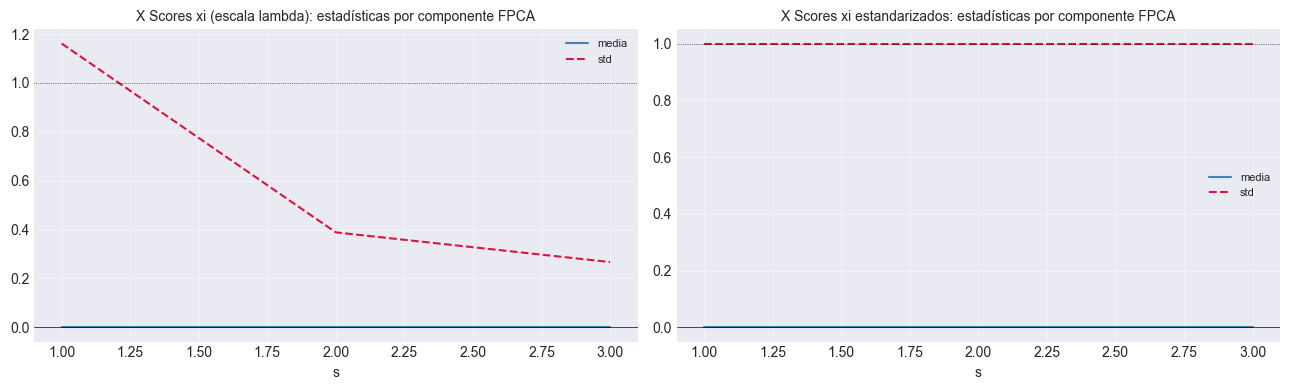

In [20]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
      f"({_chk['etiqueta_ajuste']}) → ok={_chk['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(f"\nSCORES_STD {SCORES_STD.shape}")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (aprox 0)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (aprox 0)")
print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")

# La estandarización es lineal: la asimetría debe conservarse exactamente.
_a_antes   = _asim_curt(SCORES_train)[0]
_a_despues = _asim_curt(SCORES_STD_train)[0]
assert np.allclose(_a_antes, _a_despues, atol=1e-10), \
    "La estandarización alteró la asimetría de los scores: no puede ser lineal."
print(f"  asimetría de los scores (invariante a la estandarización): "
      f"{np.array2string(_a_despues, precision=3)}")

guardar_estandarizador(PATHS, scores_standardizer)
_res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                    meta_extra={"T0": int(T0)})
print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores xi (escala lambda)", "Scores xi estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
plt.show()

### 4.2 Diagnóstico de rezagos (sólo train)

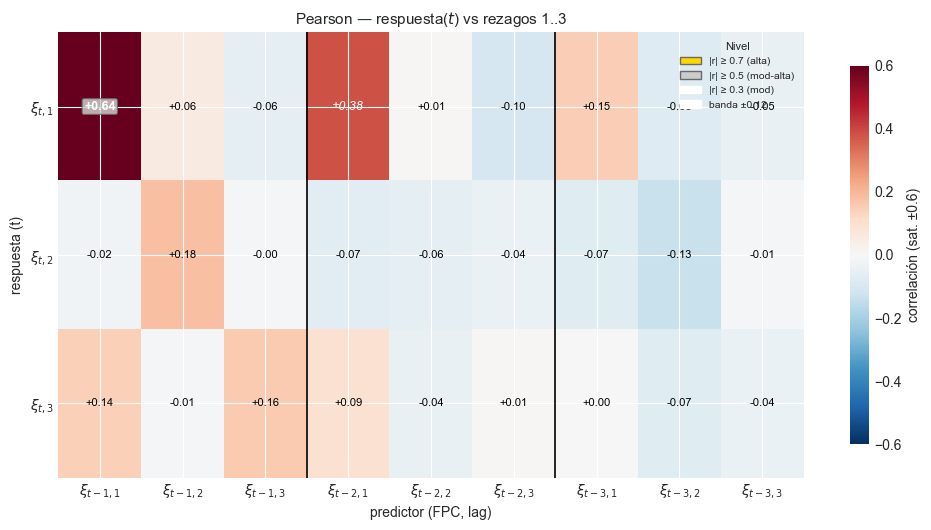

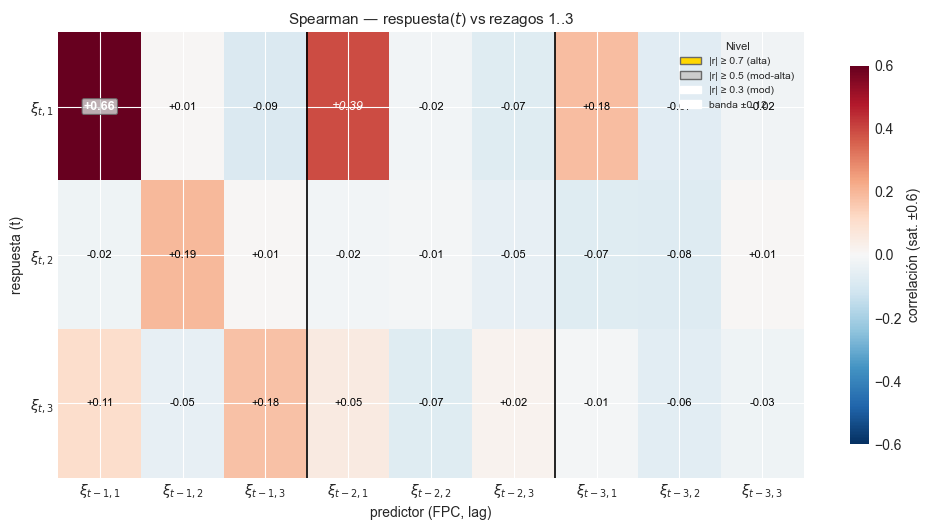

residuo de la regresión lineal score_t ~ score_{t-1}, por componente:
  FPC 1: phi_ols=+0.643  asimetría=-1.252  curtosis=5.278  <- asimetría apreciable
  FPC 2: phi_ols=+0.187  asimetría=-0.652  curtosis=4.692  <- asimetría apreciable
  FPC 3: phi_ols=+0.159  asimetría=+0.038  curtosis=3.686

máx |corr| en los rezagos (Pearson): 0.640   (banda de ruido 0.118)


In [21]:
N_LAGS_MAX = 3
T_theta, K_total = SCORES_STD_train.shape

def _spearman(Y, Xm):
    """Spearman columna a columna vía rangos (pandas, sin scipy)."""
    Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
    Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
corr_s = np.zeros_like(corr_p)
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
    sp = _spearman(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_s[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(len(y_block))

for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
    plot_rezagos_heatmap(
        M_corr, col_labels, row_labels,
        title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}",
        n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
        save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
    plt.show()

# Panel propio del escenario: asimetría del residuo de la regresión lineal de
# cada score sobre su propio rezago. Un modelo gaussiano la supone nula.
print("residuo de la regresión lineal score_t ~ score_{t-1}, por componente:")
_Z = SCORES_STD_train
for k in range(K_total):
    _y, _x = _Z[1:, k], _Z[:-1, k]
    _b = float((_x @ _y) / max(float(_x @ _x), 1e-12))
    _e = _y - _b * _x
    _a, _c = _asim_curt(_e[:, None])
    marca = "  <- asimetría apreciable" if abs(float(_a[0])) > 0.3 else ""
    print(f"  FPC {k+1}: phi_ols={_b:+.3f}  asimetría={float(_a[0]):+.3f}  "
          f"curtosis={float(_c[0]):.3f}{marca}")
print(f"\nmáx |corr| en los rezagos (Pearson): {np.abs(corr_p).max():.3f}   "
      f"(banda de ruido {band:.3f})")

### 4.3 `[CONFIG]` Orden AR y construcción de los datasets

Los rezagos del primer origen de prueba vienen del final del bloque de
entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
que su uso es el condicionamiento de la predicción a $h=1$, no fuga.

In [22]:
N_LAGS        = 1
COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

n_components = len(COMPONENT_IDX)
n_train_eff  = T0 - N_LAGS
n_test_eff   = T - T0

assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
             for lag in range(1, N_LAGS + 1)
             for j in range(n_components)]

print(f"componentes : {n_components} → índices {COMPONENT_IDX}")
print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
print(f"cov_names   : {cov_names}")

componentes : 3 → índices [0, 1, 2]
N_LAGS      : 1   ·   p = 3 covariables
n_train_eff : 279   n_test_eff : 120
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1']


In [23]:
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

def _dataset_bloque(k, t_ini, t_fin):
    """Respuesta en t en [t_ini, t_fin) y predictores en t-1 … t-N_LAGS."""
    t_idx  = np.arange(t_ini, t_fin)
    X_cols = np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
    "ajuste_en": "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
for k in range(n_components):
    print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (279, 4) · test (120, 4)
  fpc_2: train (279, 4) · test (120, 4)
  fpc_3: train (279, 4) · test (120, 4)


## 5. `[CONFIG]` Hiperparámetros y configuración MCMC

Esto es el **contrato con MATLAB**: `psbp_fd_iteracion.m` lee estos valores del
JSON y no los tiene escritos a mano, incluida `seed_base`.

Ojo con la doble acepción de `M`: aquí, dentro de `mcmc_config`, es el tamaño
de la grilla de localización $G^*$ del stick-breaking, **no** el número de
componentes FPCA. `N` es el truncamiento del número de átomos.

In [24]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 35, "M": 35}
N_CHAINS    = 3

print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS} cadenas por componente "
      f"→ {N_CHAINS * n_components} jobs en MATLAB")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) × {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")


MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 35, 'M': 35}
N_CHAINS    : 3 cadenas por componente → 9 jobs en MATLAB
Draws posteriores por score: (2000 - 500) × 3 = 4500


In [25]:
# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

def _clasificar(nombre, k_modelo):
    return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
            else "cross_lag")

HYPERPARAMS_LIST = []
for k in range(n_components):
    tipos = [_clasificar(nm, k) for nm in cov_names]
    vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
    HYPERPARAMS_LIST.append({**HP_GLOBAL,
        "apij": vals[:, 0], "bpij": vals[:, 1],
        "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
    for j, nm in enumerate(cov_names):
        a, b = hp["apij"][j], hp["bpij"][j]
        marca = "  <-" if _clasificar(nm, k) == "own_lag1" else ""
        print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
              f"{a/(a+b):>7.3f}{marca}")


Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  <-
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  <-
  fpc_3_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             own_lag1       9.0    1.0   0.900  <-


In [26]:
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "seed_base + chain*9973 + k*31",
    "escenario_id": int(ESCENARIO_ID),
    "replica_id":   int(REPLICA_ID),
    "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
    "scores_scale": "standardized_zscore_ddof0",
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": [
        {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
         "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                         for key, v in HYPERPARAMS_LIST[k].items()}}
        for k in range(n_components)
    ],
}
guardar_hiperparametros(PATHS, hp_artifact)
print(f"OK  hyperparameters.json → {PATHS['out_artefact']}")

OK  hyperparameters.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_4_r01


## 6. Configuración de evaluación, líneas base y verificación del contrato

`objetivo_evaluacion` y `modo_residuo` se declaran aquí porque cambian el
significado de toda la evaluación y no deben quedar como una decisión implícita
del notebook `_04`.

In [27]:
eval_config = {
    "scheme":      "holdout_temporal",
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "horizons":    [1],
    "n_lags":      int(N_LAGS),
    "scores_scale": "standardized_zscore_ddof0",
    # Contra QUÉ se mide el error y con qué banda:
    #   curva_verdadera + modo_residuo "ninguno" ⇒ la banda cubre la curva
    #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau).
    "objetivo_evaluacion": "curva_verdadera",
    "modo_residuo":        "ninguno",
    "nivel_credibilidad":  0.95,
    "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
    "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    # Eje 2: NO hay estado latente por el cual estratificar en este escenario.
    "estratificacion": None,
    "estratificacion_motivo": (
        "El Algoritmo 4 no tiene estado latente: la asimetría es una propiedad "
        "constante de la ley de la innovación, no un régimen ni un nivel de "
        "volatilidad que cambie de origen a origen. Estratificar por cuantiles "
        "de una cantidad observada inventaría un eje que el generador no tiene. "
        "14_04 omite la sección de calibración condicional, como la corrida 11."
    ),
    # Propio del Algoritmo 4: la FORMA de la predictiva. 14_04 §9 contrasta la
    # asimetría de los draws contra estas cifras del generador.
    "forma_predictiva": {
        "familia":                     SIM_CFG.familia,
        "delta_skew":                  float(SIM_CFG.delta_skew),
        "nu":                          float(SIM_CFG.nu),
        "asimetria_innovacion":        float(salida.diagnostico["asimetria_innovacion_empirica"]),
        "curtosis_innovacion":         float(salida.diagnostico["curtosis_innovacion_empirica"]),
        "asimetria_curvas":            float(salida.diagnostico["asimetria_curvas_media"]),
        "curtosis_curvas":             float(salida.diagnostico["curtosis_curvas_media"]),
        "asimetria_scores_train":      [float(a) for a in asim_score[:M_fpca]],
        "curtosis_scores_train":       [float(c) for c in curt_score[:M_fpca]],
        "fuente":                      "reports/.../10_momentos_curva.csv",
        "respaldo":                    f"raw/escenario_{ESCENARIO_ID}.npz::interno_operador",
    },
    # Referencia para la comparación que da sentido al escenario.
    "comparacion_de_referencia": {
        "experiment_id": "escenario_1_r01",
        "motivo": ("Misma dinámica (gamma=0.30, ||Psi||_HS=0.70, ell=0.2) y misma "
                   "representación; sólo cambia la ley de la innovación. RMSE y R2 "
                   "deberían coincidir; CRPS, energía y PIT son donde debe verse "
                   "la diferencia."),
    },
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")
for k, v in eval_config.items():
    print(f"  {k:26s}: {v}")

[out_artefact] eval_config.json
  scheme                    : holdout_temporal
  T                         : 400
  T0                        : 280
  prop_train                : 0.7
  horizons                  : [1]
  n_lags                    : 1
  scores_scale              : standardized_zscore_ddof0
  objetivo_evaluacion       : curva_verdadera
  modo_residuo              : ninguno
  nivel_credibilidad        : 0.95
  ventana_movil             : {'w': [10, 20, 40], 'paso': 1, 'solapadas': True}
  metrics_scores            : ['RMSE', 'R2', 'razon_dispersion']
  metrics_curvas            : ['MISE', 'RMSE_funcional']
  metrics_dist              : ['CRPS', 'energy_score', 'cobertura_95', 'PIT']
  estratificacion           : None
  estratificacion_motivo    : El Algoritmo 4 no tiene estado latente: la asimetría es una propiedad constante de la ley de la innovación, no un régimen ni un nivel de volatilidad que cambie de origen a origen. Estratificar por cuantiles de una cantidad observada 

In [28]:
# Líneas base a h=1: el piso que el PSBP-FD debe superar.
baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                               fpca=fpca, X_obs=X_true, tau=grilla, h=1)
baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1, contra la curva VERDADERA"))

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,120.0000,0.8740,1.0464,1.0864,1.0023,-0.0157,1.3178,1.1480
persistencia_lag1,120.0000,0.7908,1.2635,1.3847,1.1463,-0.3214,1.2576,1.1214
